In [1]:
!pip install sbi -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 658.2 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 517.9/517.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.6/271.6 kB 15.7 MB/s eta 0:00:00


In [43]:
from google.colab import files
uploaded = files.upload()

Saving src.zip to src (1).zip


In [44]:
!unzip -o src.zip
!touch src/__init__.py
!ls src

Archive:  src.zip
  inflating: src/ddm_simulator.py    
  inflating: src/plotting.py         
  inflating: src/sbi_pipeline.py     
  inflating: src/summary_statistics.py  
ddm_simulator.py  plotting.py  sbi_pipeline.py
__init__.py	  __pycache__  summary_statistics.py


In [45]:
import os
import sys
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

from sbi.inference import NPE
from sbi.utils import BoxUniform

sys.path.append(".")

from src.ddm_simulator import simulate_ddm_dataset
from src.summary_statistics import summarize_behavior
from src.sbi_pipeline import ddm_sbi_simulator, run_trial_count_experiment
from src.plotting import (
    plot_reaction_time_distribution,
    plot_posterior_parameters,
    plot_true_vs_inferred,
    plot_uncertainty_vs_trials
)

torch.manual_seed(42)
np.random.seed(42)

os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("data", exist_ok=True)

In [46]:
true_params = {
    "drift_rate": 1.2,
    "boundary": 1.0,
    "non_decision_time": 0.25
}

param_names = ["drift_rate", "boundary", "non_decision_time"]

true_values = torch.tensor([
    true_params["drift_rate"],
    true_params["boundary"],
    true_params["non_decision_time"]
])

In [47]:
reaction_times, choices = simulate_ddm_dataset(
    drift_rate=true_params["drift_rate"],
    boundary=true_params["boundary"],
    non_decision_time=true_params["non_decision_time"],
    n_trials=300
)

observed_data_df = pd.DataFrame({
    "reaction_time": reaction_times,
    "choice": choices
})

observed_data_df.to_csv("data/simulated_observed_data.csv", index=False)

print("Mean RT:", reaction_times.mean())
print("Choice-1 proportion:", choices.mean())

Mean RT: 0.9914499999999977
Choice-1 proportion: 0.93


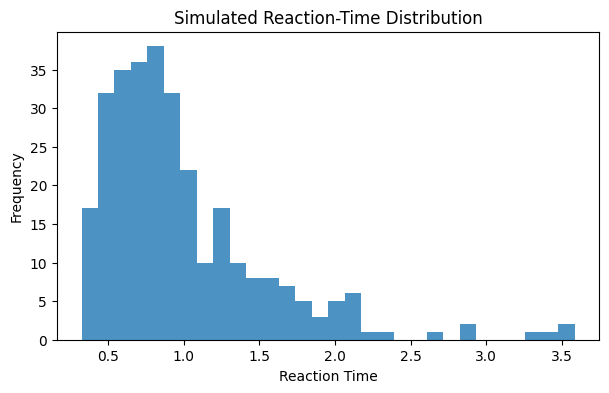

In [48]:
plot_reaction_time_distribution(
    reaction_times,
    save_path="figures/simulated_rt_distribution.png"
)

In [49]:
x_observed = summarize_behavior(reaction_times, choices)
x_observed_tensor = torch.tensor(x_observed, dtype=torch.float32)

x_observed

array([0.99145   , 0.54886123, 0.93      , 0.48      , 0.84      ,
       1.6985    ])

In [50]:
prior = BoxUniform(
    low=torch.tensor([0.2, 0.5, 0.1]),
    high=torch.tensor([2.5, 2.0, 0.6])
)

In [51]:
num_simulations = 1000

theta_samples = prior.sample((num_simulations,))
x_samples = []

for i, theta in enumerate(theta_samples):
    x = ddm_sbi_simulator(theta)
    x_samples.append(x)

    if (i + 1) % 100 == 0:
        print(f"Completed {i + 1}/{num_simulations} simulations")

x_samples = torch.stack(x_samples)

print(theta_samples.shape)
print(x_samples.shape)

Completed 100/1000 simulations
Completed 200/1000 simulations
Completed 300/1000 simulations
Completed 400/1000 simulations
Completed 500/1000 simulations
Completed 600/1000 simulations
Completed 700/1000 simulations
Completed 800/1000 simulations
Completed 900/1000 simulations
Completed 1000/1000 simulations
torch.Size([1000, 3])
torch.Size([1000, 6])


In [52]:
inference = NPE(prior=prior)

density_estimator = inference.append_simulations(
    theta_samples,
    x_samples
).train()

posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 272 epochs.

In [53]:
posterior_samples = posterior.sample(
    (2000,),
    x=x_observed_tensor
)

posterior_mean = posterior_samples.mean(dim=0)
posterior_std = posterior_samples.std(dim=0)

  0%|          | 0/2000 [00:00<?, ?it/s]

In [54]:
results_df = pd.DataFrame({
    "parameter": param_names,
    "true_value": true_values.numpy(),
    "posterior_mean": posterior_mean.detach().numpy(),
    "posterior_std": posterior_std.detach().numpy()
})

results_df.to_csv("results/parameter_recovery_results.csv", index=False)

results_df

,parameter,true_value,posterior_mean,posterior_std
0,drift_rate,1.20,1.208901,0.074891
1,boundary,1.00,1.016379,0.050232
2,non_decision_time,0.25,0.235829,0.025104


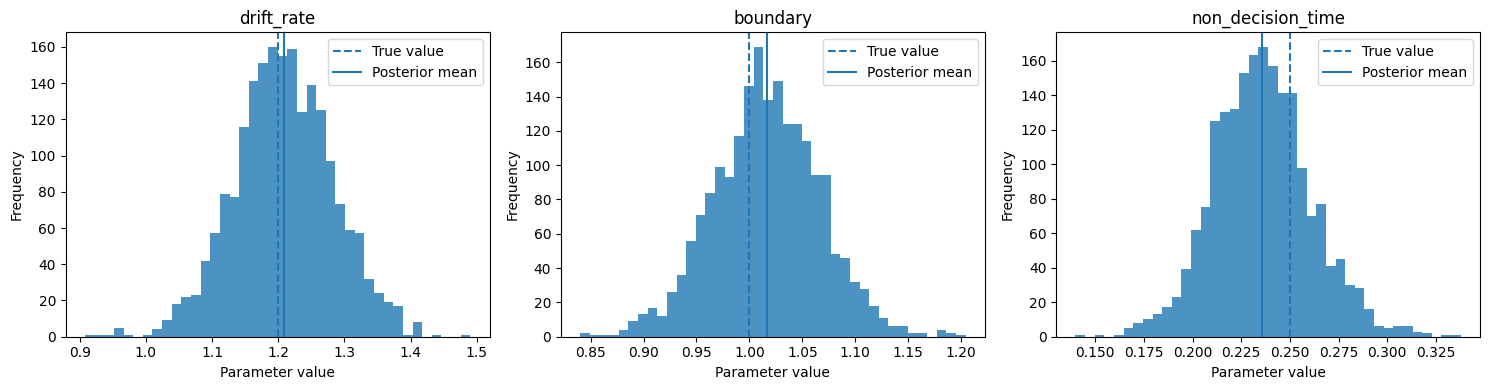

In [55]:
plot_posterior_parameters(
    posterior_samples=posterior_samples,
    true_values=true_values,
    posterior_mean=posterior_mean,
    param_names=param_names,
    save_path="figures/posterior_parameters.png"
)

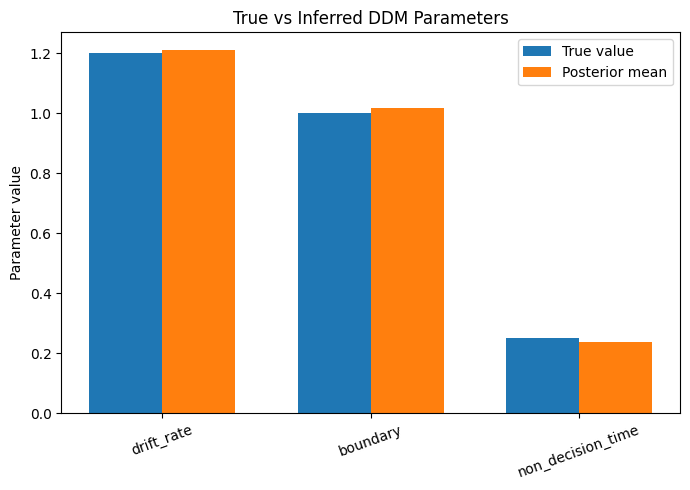

In [56]:
plot_true_vs_inferred(
    results_df=results_df,
    param_names=param_names,
    save_path="figures/true_vs_inferred_parameters.png"
)

In [57]:
trial_counts = [25, 50, 100, 200, 500]

uncertainty_results = []

for n_trials in trial_counts:
    print(f"Running inference for {n_trials} observed trials...")

    mean_temp, std_temp = run_trial_count_experiment(
        posterior=posterior,
        true_params=true_params,
        n_observed_trials=n_trials,
        n_posterior_samples=1000
    )

    for i, name in enumerate(param_names):
        uncertainty_results.append({
            "n_trials": n_trials,
            "parameter": name,
            "posterior_mean": mean_temp[i].item(),
            "posterior_std": std_temp[i].item()
        })

uncertainty_df = pd.DataFrame(uncertainty_results)

uncertainty_df.to_csv("results/uncertainty_vs_trials.csv", index=False)

uncertainty_df

Running inference for 25 observed trials...
Running inference for 50 observed trials...
Running inference for 100 observed trials...
Running inference for 200 observed trials...
Running inference for 500 observed trials...


,n_trials,parameter,posterior_mean,posterior_std
0,25,drift_rate,1.278894,0.088241
1,25,boundary,1.175495,0.063539
2,25,non_decision_time,0.159053,0.028724
3,50,drift_rate,1.119223,0.068246
4,50,boundary,1.025833,0.050154
5,50,non_decision_time,0.242445,0.026091
6,100,drift_rate,1.214208,0.075865
7,100,boundary,1.011916,0.051246
8,100,non_decision_time,0.247452,0.024521
9,200,drift_rate,1.200452,0.076612


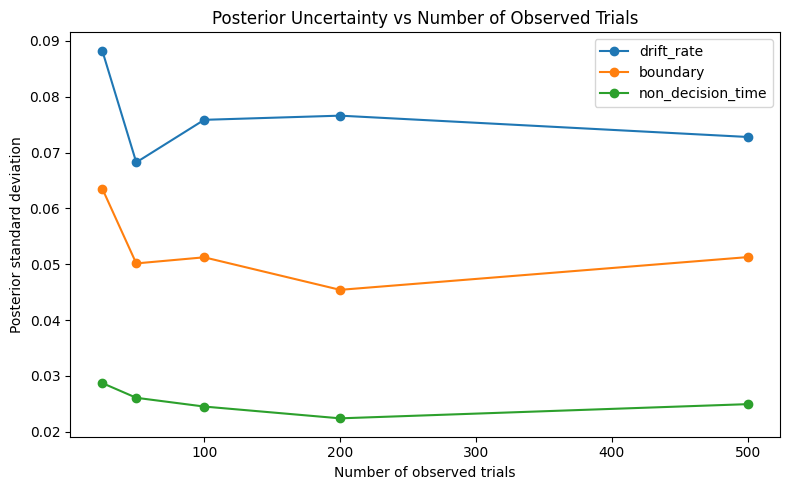

In [58]:
plot_uncertainty_vs_trials(
    uncertainty_df=uncertainty_df,
    param_names=param_names,
    save_path="figures/uncertainty_vs_trials.png"
)

In [59]:
!ls figures
!ls results
!ls data

posterior_parameters.png       true_vs_inferred_parameters.png
simulated_rt_distribution.png  uncertainty_vs_trials.png
parameter_recovery_results.csv	uncertainty_vs_trials.csv
simulated_observed_data.csv


In [60]:
from google.colab import files

files.download("figures/simulated_rt_distribution.png")
files.download("figures/posterior_parameters.png")
files.download("figures/true_vs_inferred_parameters.png")
files.download("figures/uncertainty_vs_trials.png")
files.download("results/parameter_recovery_results.csv")
files.download("results/uncertainty_vs_trials.csv")
files.download("data/simulated_observed_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>